In [60]:
import pandas as pd
import os
import pyreadr
from nltk.stem import SnowballStemmer as sns
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer


# Set Working Directory
os.chdir(r"D:\Projektfolder1 (Miethe, Grosenick)\zz_AmelieMisc\thankyou")

# set output path
output_dir = r'data\predict_citations'




In [ ]:
# load data

# Load R file from data/gen subfolder
result = pyreadr.read_r(r'data\gen\dt_paper_level.RData')


In [8]:
# keep just some columns, show columns
df = result['dt_paper_level']
print(df.columns)

# keep just some columns and make unique
df = df[['paper_id', 'title_paper', 'abstract', 'field', 'publication_year']].drop_duplicates()

Index(['paper_id', 'title_paper', 'publication_year', 'person_id', 'name',
       'publication_type', 'authors', 'author_full_names', 'journal_short',
       'doi',
       ...
       'author_342', 'author_343', 'avg_score', 'top5_repec', 'gender',
       'd_female', 'abstract', 'author_keywords', 'keywords_plus', 'field'],
      dtype='object', length=368)


In [11]:
# stem titles and abstracts

df_titles = df['title_paper']
df_abstract = df['abstract']



stemmer = sns("english")
 
def stem(string):
        "splits and stemms a string variable and removes stopwords"
        stems = [stemmer.stem(word) for word in string.lower().split()]
        return " ".join(stems)
 
print("Stemming text")
df_titles = df_titles.apply(stem) 
print(df_titles.head())

# create tf-idf matrix for titles
print("Creating tf-idf matrix for titles")
vectorizer = TfidfVectorizer()
tfidf_matrix_titles = vectorizer.fit_transform(df_titles)
print(tfidf_matrix_titles.shape)

Stemming text
0     act wife': marriag market incent and labor mar...
19    get to denmark': the role of agricultur elit f...
20    ghost citizens': use notch to identifi manipul...
24                          (almost) model-fre recoveri
43                       (il)leg assign in school choic
Name: title_paper, dtype: object
Creating tf-idf matrix for titles
(7926, 6358)


Claude:
The cleanest approach for your setting would be: train ridge regression on your 8,000 papers using title + abstract n-grams with tf-idf, 10-fold CV to select lambda, citations standardized by cohort-year and winsorized. If you can augment with external economics papers for training and then predict on your 8,000, even better. The core method transfers directly — you're in better shape than the original paper in one respect (you have abstracts), and the smaller sample is manageable given ridge's properties.

### 1. a) Ridge Regression w/o any improvements: Model

In [ ]:
import pandas as pd
import numpy as np
from nltk.stem.snowball import SnowballStemmer as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

# ── 0. Setup ──────────────────────────────────────────────────────────────────
stemmer = sns("english")
stop_words = set(stopwords.words("english"))

def stem(string):
    """Splits, lowercases, removes stopwords, and stems a string."""
    if not isinstance(string, str):
        return ""
    tokens = [
        stemmer.stem(word)
        for word in string.lower().split()
        if word not in stop_words
    ]
    return " ".join(tokens)



# load data
# Load R file from data/gen subfolder
result = pyreadr.read_r(r'data\gen\dt_paper_level.RData')
df = result['dt_paper_level']
df = df.rename(columns={'times_cited_all_databases': 'citations'})

# ── 1. Prep dataframe ─────────────────────────────────────────────────────────
# Reset index immediately after filtering so positional index = row index
# This is the key step that ensures paper_id alignment throughout

df = (
    df[['paper_id', 'title_paper', 'abstract', 'field',
        'publication_year', 'citations']]
    .sort_values('publication_year', ascending=False)
    .drop_duplicates(subset='paper_id', keep='first')
    .reset_index(drop=True)   # <-- guarantees 0,1,2,... index
)

# Convert citations to numeric, coerce errors to NaN
df['citations'] = pd.to_numeric(df['citations'], errors='coerce')

# Remove rows with NaN citations
df = df.dropna(subset=['citations'])

# Sanity check: paper_id must be unique after deduplication
assert df['paper_id'].is_unique, "paper_id is not unique after drop_duplicates!"
print(f"Working with {len(df)} papers")

# ── 2. Stem titles and abstracts ──────────────────────────────────────────────
# Work on df columns directly (not detached series) so index stays tied to df
print("Stemming titles...")
df['title_stemmed']    = df['title_paper'].fillna("").apply(stem)

print("Stemming abstracts...")
df['abstract_stemmed'] = df['abstract'].fillna("").apply(stem)

# Verify no rows were added/dropped during stemming
assert len(df['title_stemmed']) == len(df), "Title stemming changed row count!"
assert len(df['abstract_stemmed']) == len(df), "Abstract stemming changed row count!"

# ── 3. Standardize citations within publication year AND field ──────────────
def winsorize_by_year_field(df, col='citations', pct=0.99):
    df = df.copy()
    df['citations_wins'] = df.groupby(['publication_year', 'field'])[col].transform(
        lambda x: x.clip(upper=x.quantile(pct))
    )
    return df

df = winsorize_by_year_field(df)

df['citations_std'] = df.groupby(['publication_year', 'field'])['citations_wins'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x - x.mean()
)

# ── 4. Build TF-IDF matrices ──────────────────────────────────────────────────
# Pass df['col'].tolist() rather than the series itself -- this is the safest
# way to ensure the vectorizer processes rows in df's exact order
print("Building TF-IDF matrix for titles...")
vec_titles = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_titles = vec_titles.fit_transform(df['title_stemmed'].tolist())
print(f"  Title matrix shape: {X_titles.shape}")
assert X_titles.shape[0] == len(df), "Title matrix row count mismatch!"

print("Building TF-IDF matrix for abstracts...")
vec_abstracts = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_abstracts = vec_abstracts.fit_transform(df['abstract_stemmed'].tolist())
print(f"  Abstract matrix shape: {X_abstracts.shape}")
assert X_abstracts.shape[0] == len(df), "Abstract matrix row count mismatch!"

# Title length indicators
title_lengths = df['title_paper'].fillna("").apply(lambda x: len(x.split()))
title_length_dummies = pd.get_dummies(
    title_lengths.clip(upper=30).astype(int),
    prefix='title_len'
)
X_title_len = csr_matrix(title_length_dummies.values)
assert X_title_len.shape[0] == len(df), "Title length matrix row count mismatch!"

# Abstract length
abstract_lengths = df['abstract_stemmed'].apply(lambda x: len(x.split()))
abstract_length_dummies = pd.get_dummies(
    abstract_lengths.clip(upper=50).astype(int),
    prefix='abstract_len'
)
X_abstract_len = csr_matrix(abstract_length_dummies.values)
assert X_abstract_len.shape[0] == len(df), "Abstract length matrix row count mismatch!"

# Stack all features
# X = hstack([X_titles, X_abstracts, X_title_len, X_abstract_len])
X = hstack([X_titles, X_abstracts])
print(f"Combined feature matrix shape: {X.shape}")
assert X.shape[0] == len(df), "Final feature matrix row count mismatch!"

y = df['citations_std'].values
assert len(y) == len(df), "Target vector length mismatch!"

# ── 5. Ridge regression with 10-fold CV ──────────────────────────────────────
print("\nFitting RidgeCV...")
alphas = np.logspace(0, 4, 50)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=kf,
    scoring='r2',
    fit_intercept=True
)
ridge.fit(X, y)

print(f"  Best alpha (lambda): {ridge.alpha_:.2f}")
print(f"  In-sample R²:        {ridge.score(X, y):.3f}")

# ── 6. Attach predictions back to df by position ─────────────────────────────
# Because we reset_index and verified shapes throughout, row i of X
# corresponds exactly to row i of df, which has a known paper_id
df['citations_predicted'] = ridge.predict(X)

# Verify predictions were assigned correctly by spot-checking a few rows
print("\nSpot check -- first 5 rows:")
print(df[['paper_id', 'title_paper', 'citations_std',
          'citations_predicted']].head())

# ── 7. Diagnostic: R² by publication year ────────────────────────────────────
from sklearn.metrics import r2_score

print("\nR² by publication year:")
for yr, grp in df.groupby('publication_year'):
    if len(grp) > 10:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        print(f"  {yr}: n={len(grp):5d}  R²={r2:.3f}")

# ── 8. Save with paper_id as anchor ──────────────────────────────────────────
out = df[['paper_id', 'publication_year', 'citations',
          'citations_wins', 'citations_std', 'citations_predicted']]

# Final check: output row count matches input
assert len(out) == len(df), "Output row count does not match input!"
print(f"\nFinal output: {len(out)} rows")



Working with 7925 papers
Stemming titles...
Stemming abstracts...
Building TF-IDF matrix for titles...
  Title matrix shape: (7925, 2368)
Building TF-IDF matrix for abstracts...
  Abstract matrix shape: (7925, 19752)
Combined feature matrix shape: (7925, 22120)

Fitting RidgeCV...
  Best alpha (lambda): 5.43
  In-sample R²:        0.445

Spot check -- first 5 rows:
   paper_id                                        title_paper  citations_std  \
0      5067  Present Bias Unconstrained: Consumption, Welfa...      -0.442317   
1      7057  The impact of increased exposure of diversity ...      -0.751463   
2      7056                     The impact of impact investing       5.581080   
3      7066  The impact of violence on the dynamics of migr...      -0.531848   
4      5137   Pro-social preferences and the paradox of voting      -0.531848   

   citations_predicted  
0            -0.083789  
1             0.029954  
2             1.370276  
3             0.046499  
4            -0.3462

### 1. b) Ridge Regression w/o any improvements: Fit

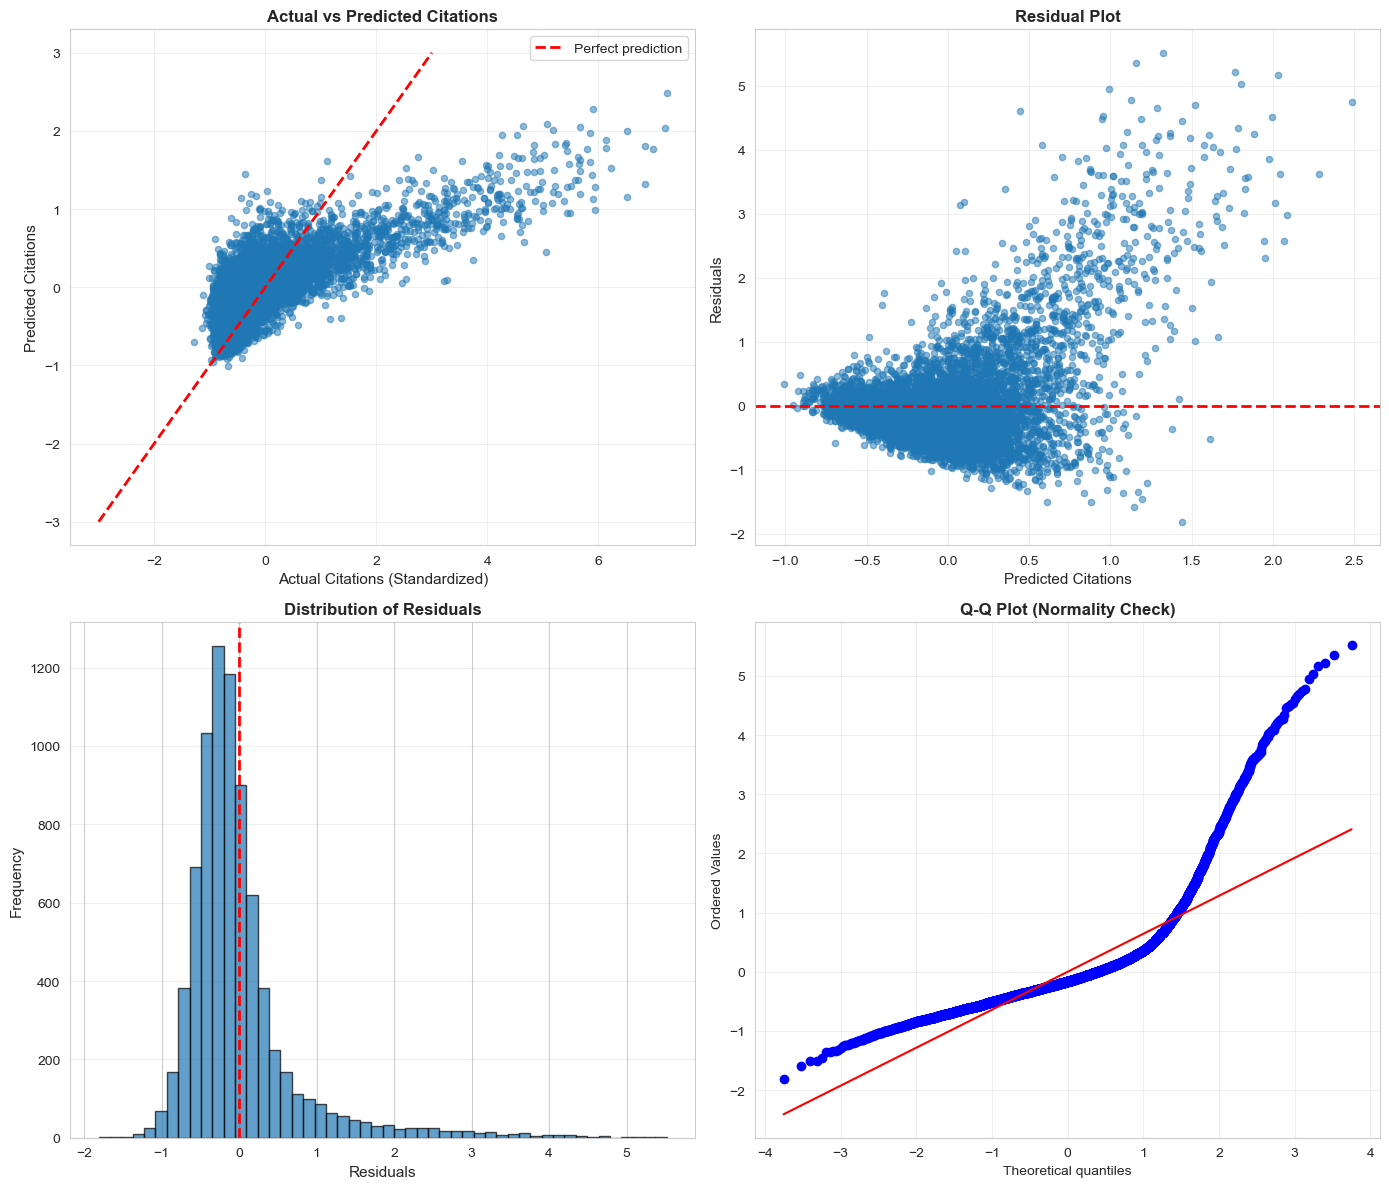

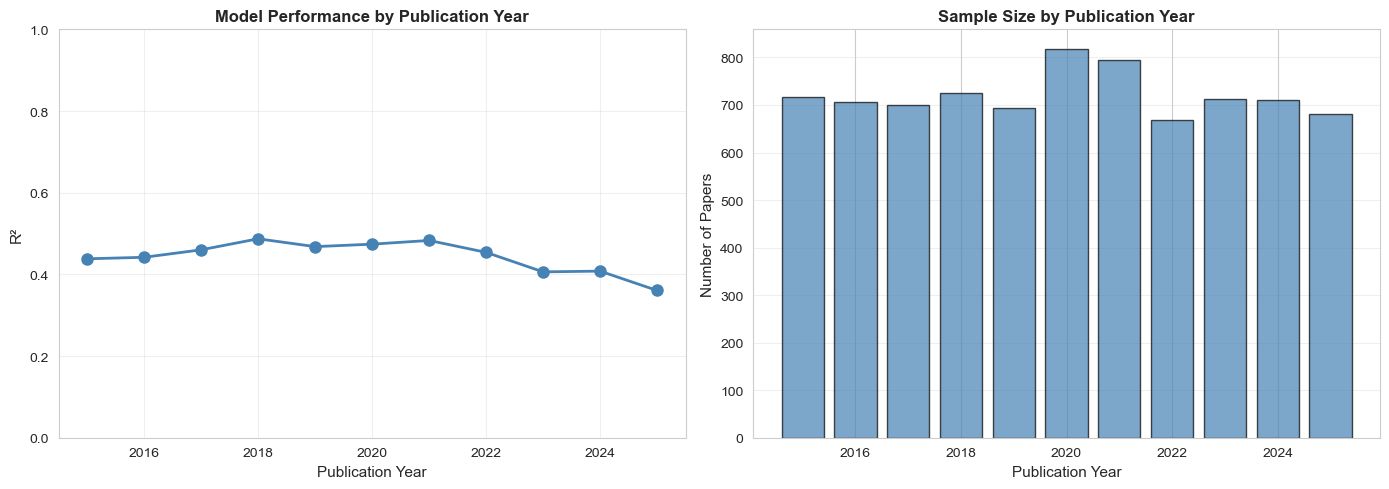

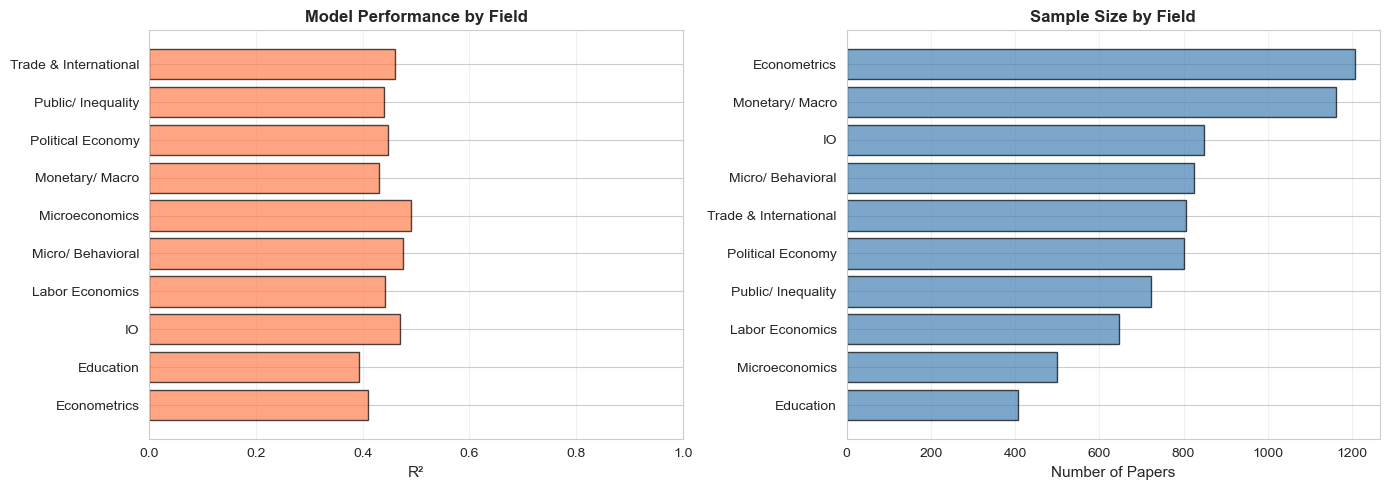

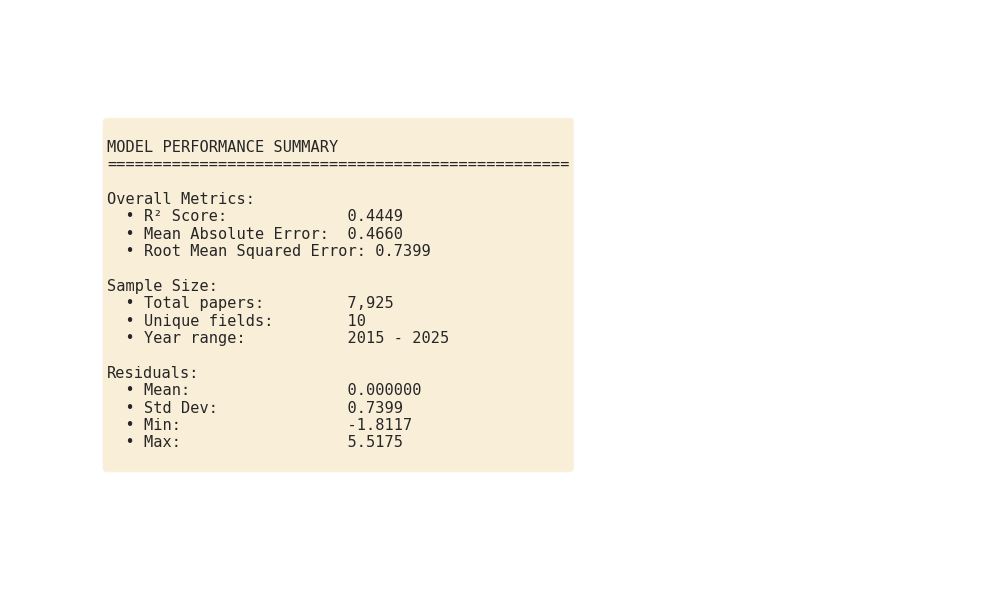

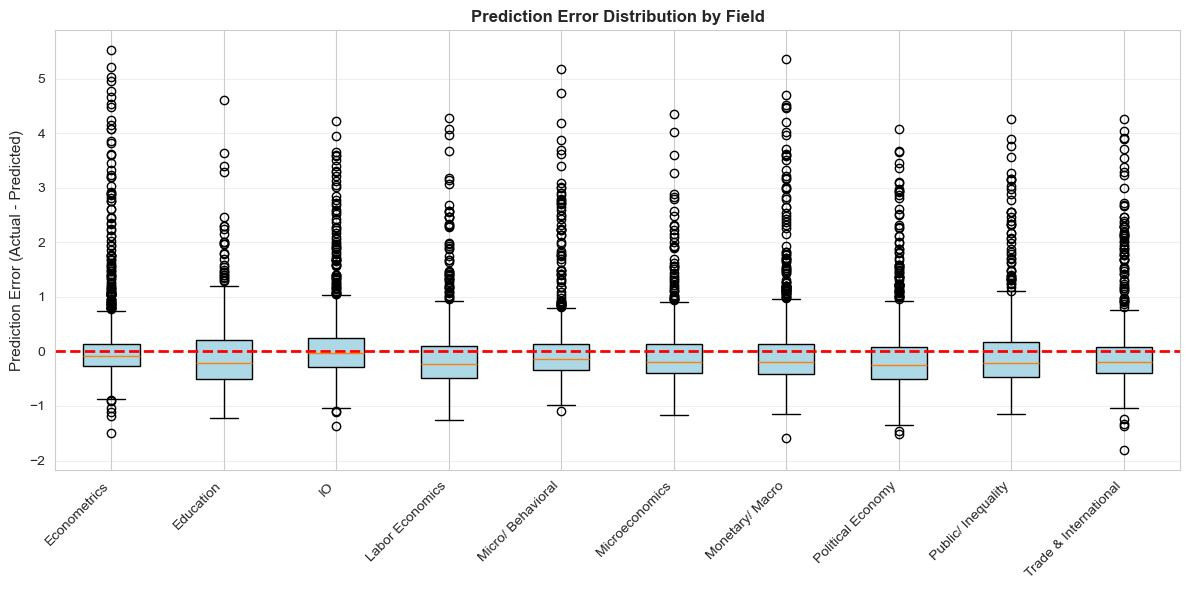


✓ All plots generated successfully!


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ── 1. Actual vs Predicted (Overall) ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scatter plot
ax = axes[0, 0]
ax.scatter(df['citations_std'], df['citations_predicted'], alpha=0.5, s=20)
ax.plot([-3, 3], [-3, 3], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Citations (Standardized)', fontsize=11)
ax.set_ylabel('Predicted Citations', fontsize=11)
ax.set_title('Actual vs Predicted Citations', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals
ax = axes[0, 1]
residuals = df['citations_std'] - df['citations_predicted']
ax.scatter(df['citations_predicted'], residuals, alpha=0.5, s=20)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Citations', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Residual distribution
ax = axes[1, 0]
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Residuals', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Q-Q plot (normality check)
from scipy import stats
ax = axes[1, 1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 2. R² by Publication Year ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² trend over years
ax = axes[0]
r2_by_year = []
years = []
for yr in sorted(df['publication_year'].unique()):
    grp = df[df['publication_year'] == yr]
    if len(grp) > 5:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        r2_by_year.append(r2)
        years.append(yr)

ax.plot(years, r2_by_year, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('Publication Year', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Model Performance by Publication Year', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Sample size by year
ax = axes[1]
sample_counts = df.groupby('publication_year').size()
ax.bar(sample_counts.index, sample_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Publication Year', fontsize=11)
ax.set_ylabel('Number of Papers', fontsize=11)
ax.set_title('Sample Size by Publication Year', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 3. R² by Field ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² by field
ax = axes[0]
r2_by_field = []
fields = []
for field in sorted(df['field'].unique()):
    grp = df[df['field'] == field]
    if len(grp) > 5:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        r2_by_field.append(r2)
        fields.append(field)

ax.barh(fields, r2_by_field, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('R²', fontsize=11)
ax.set_title('Model Performance by Field', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

# Sample size by field
ax = axes[1]
sample_counts = df.groupby('field').size().sort_values(ascending=True)
ax.barh(sample_counts.index, sample_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Papers', fontsize=11)
ax.set_title('Sample Size by Field', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── 4. Error metrics ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

overall_r2 = r2_score(df['citations_std'], df['citations_predicted'])
overall_mae = mean_absolute_error(df['citations_std'], df['citations_predicted'])
overall_rmse = np.sqrt(mean_squared_error(df['citations_std'], df['citations_predicted']))

metrics_text = f"""
MODEL PERFORMANCE SUMMARY
{'='*50}

Overall Metrics:
  • R² Score:             {overall_r2:.4f}
  • Mean Absolute Error:  {overall_mae:.4f}
  • Root Mean Squared Error: {overall_rmse:.4f}

Sample Size:
  • Total papers:         {len(df):,}
  • Unique fields:        {df['field'].nunique()}
  • Year range:           {df['publication_year'].min():.0f} - {df['publication_year'].max():.0f}

Residuals:
  • Mean:                 {residuals.mean():.6f}
  • Std Dev:              {residuals.std():.4f}
  • Min:                  {residuals.min():.4f}
  • Max:                  {residuals.max():.4f}
"""

ax.text(0.1, 0.5, metrics_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.tight_layout()
plt.show()

# ── 5. Prediction Error Distribution by Field ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

error_data = []
field_labels = []
for field in sorted(df['field'].unique()):
    grp = df[df['field'] == field]
    errors = grp['citations_std'] - grp['citations_predicted']
    error_data.append(errors)
    field_labels.append(field)

bp = ax.boxplot(error_data, labels=field_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_ylabel('Prediction Error (Actual - Predicted)', fontsize=11)
ax.set_title('Prediction Error Distribution by Field', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n✓ All plots generated successfully!")

### 2. Ridge Regression testing what happens when adding higher-order polynomials: Model and Fit

Working with 7925 papers
Stemming titles...
Stemming abstracts...
Building TF-IDF matrix for titles...
  Title matrix shape: (7925, 2368)
Building TF-IDF matrix for abstracts...
  Abstract matrix shape: (7925, 19752)
Combined feature matrix shape: (7925, 22120)

Fitting RidgeCV...
  Best alpha (lambda): 5.43
  In-sample R²:        0.445

Spot check -- first 5 rows:
   paper_id                                        title_paper  citations_std  \
0      5067  Present Bias Unconstrained: Consumption, Welfa...      -0.442317   
1      7057  The impact of increased exposure of diversity ...      -0.751463   
2      7056                     The impact of impact investing       5.581080   
3      7066  The impact of violence on the dynamics of migr...      -0.531848   
4      5137   Pro-social preferences and the paradox of voting      -0.531848   

   citations_predicted  
0            -0.083789  
1             0.029954  
2             1.370276  
3             0.046499  
4            -0.3462

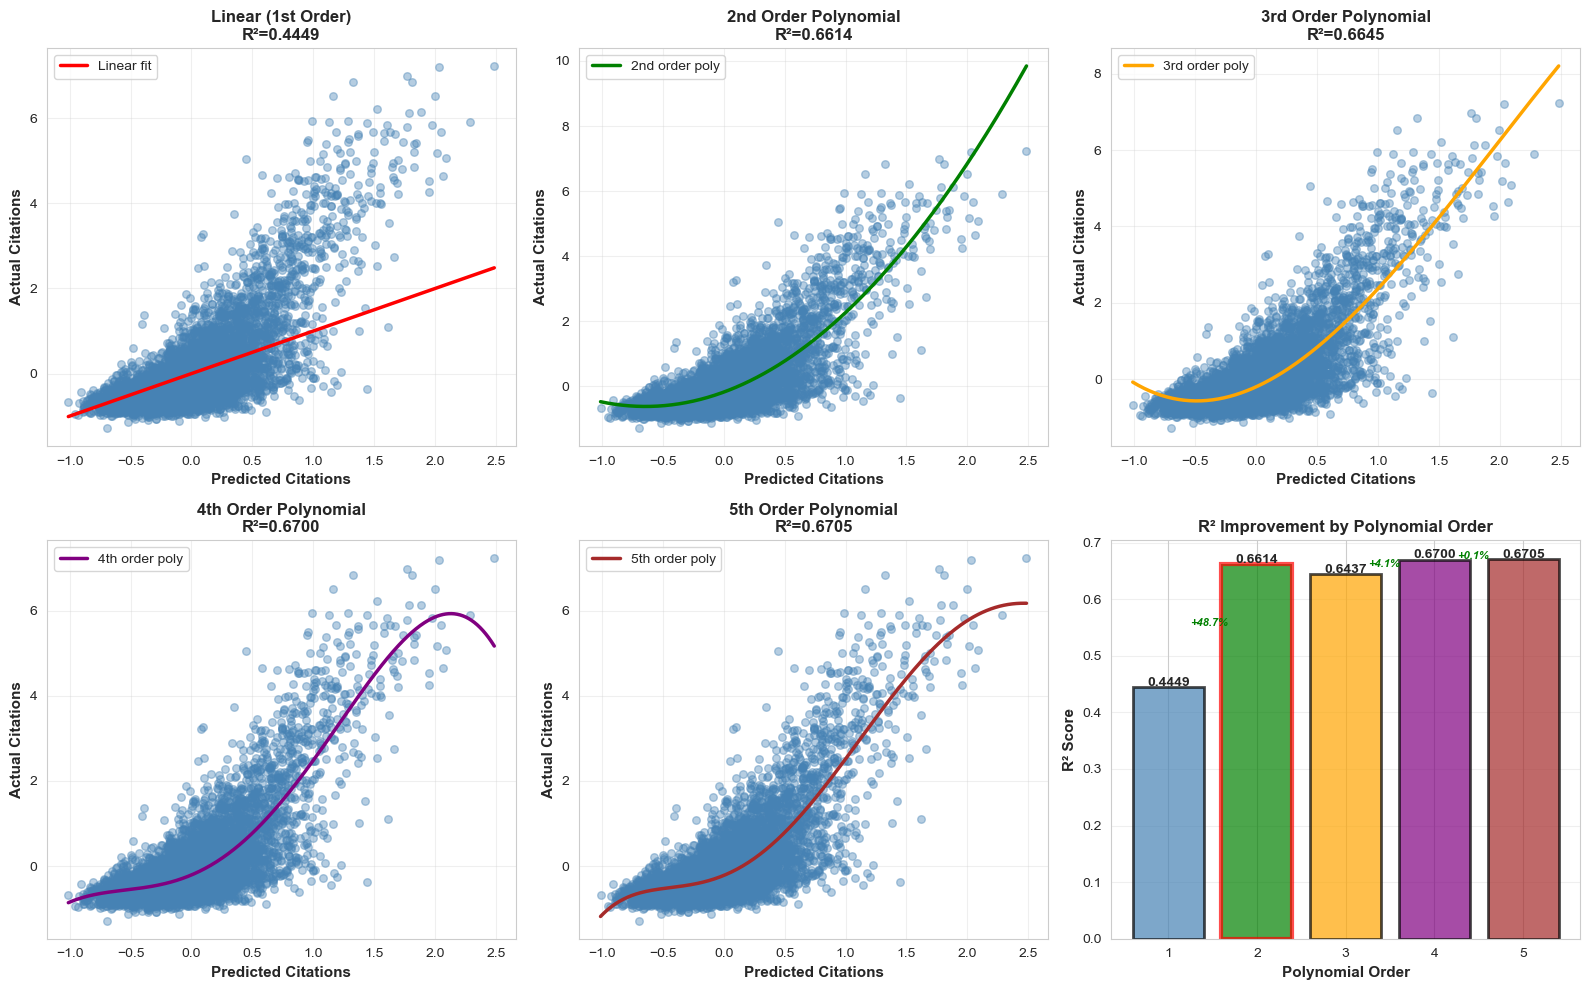


IMPROVEMENT ANALYSIS

R² Improvements:
  Order 1 → 2: +0.2165 (+48.66%)
  Order 2 → 3: +-0.0177 (+-2.67%)
  Order 3 → 4: +0.0263 (+4.08%)
  Order 4 → 5: +0.0005 (+0.08%)

Key Findings:
  • Largest jump: 1st → 2nd order (+0.2165)
  • 2nd → 3rd: +0.0031
  • 3rd → 4th: +0.0055

✓ SIMILAR TO PAPER: Main improvement at 2nd order

Polynomial with largest improvement: Order 2
Improvement from previous order: +0.2165
R² at order 2: 0.6614

Final output: 7925 rows
Done. Output saved to predicted_citations.csv (using 2-order polynomial with largest improvement)


In [ ]:
import pandas as pd
import numpy as np
from nltk.stem.snowball import SnowballStemmer as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pyreadr
import warnings
warnings.filterwarnings('ignore')

# ── 0. Setup ──────────────────────────────────────────────────────────────────
stemmer = sns("english")
stop_words = set(stopwords.words("english"))

def stem(string):
    """Splits, lowercases, removes stopwords, and stems a string."""
    if not isinstance(string, str):
        return ""
    tokens = [
        stemmer.stem(word)
        for word in string.lower().split()
        if word not in stop_words
    ]
    return " ".join(tokens)

# load data
result = pyreadr.read_r(r'data\gen\dt_paper_level.RData')
df = result['dt_paper_level']
df = df.rename(columns={'times_cited_all_databases': 'citations'})

# ── 1. Prep dataframe ─────────────────────────────────────────────────────────
df = (
    df[['paper_id', 'title_paper', 'abstract', 'field',
        'publication_year', 'citations']]
    .sort_values('publication_year', ascending=False)
    .drop_duplicates(subset='paper_id', keep='first')
    .reset_index(drop=True)
)

df['citations'] = pd.to_numeric(df['citations'], errors='coerce')
df = df.dropna(subset=['citations'])

assert df['paper_id'].is_unique, "paper_id is not unique after drop_duplicates!"
print(f"Working with {len(df)} papers")

# ── 2. Stem titles and abstracts ──────────────────────────────────────────────
print("Stemming titles...")
df['title_stemmed'] = df['title_paper'].fillna("").apply(stem)

print("Stemming abstracts...")
df['abstract_stemmed'] = df['abstract'].fillna("").apply(stem)

assert len(df['title_stemmed']) == len(df), "Title stemming changed row count!"
assert len(df['abstract_stemmed']) == len(df), "Abstract stemming changed row count!"

# ── 3. Standardize citations within publication year AND field ──────────────
def winsorize_by_year_field(df, col='citations', pct=0.99):
    df = df.copy()
    df['citations_wins'] = df.groupby(['publication_year', 'field'])[col].transform(
        lambda x: x.clip(upper=x.quantile(pct))
    )
    return df

df = winsorize_by_year_field(df)

df['citations_std'] = df.groupby(['publication_year', 'field'])['citations_wins'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x - x.mean()
)

# ── 4. Build TF-IDF matrices ──────────────────────────────────────────────────
print("Building TF-IDF matrix for titles...")
vec_titles = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_titles = vec_titles.fit_transform(df['title_stemmed'].tolist())
print(f"  Title matrix shape: {X_titles.shape}")
assert X_titles.shape[0] == len(df), "Title matrix row count mismatch!"

print("Building TF-IDF matrix for abstracts...")
vec_abstracts = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_abstracts = vec_abstracts.fit_transform(df['abstract_stemmed'].tolist())
print(f"  Abstract matrix shape: {X_abstracts.shape}")
assert X_abstracts.shape[0] == len(df), "Abstract matrix row count mismatch!"

# Stack all features
X = hstack([X_titles, X_abstracts])
print(f"Combined feature matrix shape: {X.shape}")
assert X.shape[0] == len(df), "Final feature matrix row count mismatch!"

y = df['citations_std'].values
assert len(y) == len(df), "Target vector length mismatch!"

# ── 5. Ridge regression with 10-fold CV ──────────────────────────────────────
print("\nFitting RidgeCV...")
alphas = np.logspace(0, 4, 50)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=kf,
    scoring='r2',
    fit_intercept=True
)
ridge.fit(X, y)

print(f"  Best alpha (lambda): {ridge.alpha_:.2f}")
print(f"  In-sample R²:        {ridge.score(X, y):.3f}")

# ── 6. Attach predictions back to df by position ─────────────────────────────
df['citations_predicted'] = ridge.predict(X)

print("\nSpot check -- first 5 rows:")
print(df[['paper_id', 'title_paper', 'citations_std',
          'citations_predicted']].head())

# ── 7. Diagnostic: R² by publication year ────────────────────────────────────
print("\nR² by publication year:")
for yr, grp in df.groupby('publication_year'):
    if len(grp) > 10:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        print(f"  {yr}: n={len(grp):5d}  R²={r2:.3f}")

# ──────────────────────────────────────────────────────────────────────────────
# ── POLYNOMIAL FIT ANALYSIS ──────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("POLYNOMIAL FIT ANALYSIS")
print("="*70)

# Original (linear) R²
r2_original = r2_score(df['citations_std'], df['citations_predicted'])
print(f"\nR² (Linear):           {r2_original:.4f}")

# 1st order (baseline)
r2_poly1 = r2_original

# 2nd order polynomial
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(df['citations_predicted'].values.reshape(-1, 1))
model_poly2 = LinearRegression()
model_poly2.fit(X_poly2, df['citations_std'])
y_pred_poly2 = model_poly2.predict(X_poly2)
r2_poly2 = r2_score(df['citations_std'], y_pred_poly2)
print(f"R² (2nd order poly):   {r2_poly2:.4f}")

# 3rd order polynomial
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly3.fit_transform(df['citations_predicted'].values.reshape(-1, 1))
model_poly3 = LinearRegression()
model_poly3.fit(X_poly3, df['citations_std'])
y_pred_poly3 = model_poly3.predict(X_poly3)
r3_poly3 = r2_score(df['citations_std'], y_pred_poly3)
print(f"R² (3rd order poly):   {r3_poly3:.4f}")

# 4th order polynomial
poly4 = PolynomialFeatures(degree=4, include_bias=False)
X_poly4 = poly4.fit_transform(df['citations_predicted'].values.reshape(-1, 1))
model_poly4 = LinearRegression()
model_poly4.fit(X_poly4, df['citations_std'])
y_pred_poly4 = model_poly4.predict(X_poly4)
r2_poly4 = r2_score(df['citations_std'], y_pred_poly4)
print(f"R² (4th order poly):   {r2_poly4:.4f}")

# 5th order polynomial
poly5 = PolynomialFeatures(degree=5, include_bias=False)
X_poly5 = poly5.fit_transform(df['citations_predicted'].values.reshape(-1, 1))
model_poly5 = LinearRegression()
model_poly5.fit(X_poly5, df['citations_std'])
y_pred_poly5 = model_poly5.predict(X_poly5)
r2_poly5 = r2_score(df['citations_std'], y_pred_poly5)
print(f"R² (5th order poly):   {r2_poly5:.4f}")

# ── Visualize ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

x_line = np.linspace(df['citations_predicted'].min(), df['citations_predicted'].max(), 300)

# 1st order (Linear)
ax = axes[0, 0]
ax.scatter(df['citations_predicted'], df['citations_std'], alpha=0.4, s=30, color='steelblue')
ax.plot(x_line, x_line, 'r-', lw=2.5, label='Linear fit')
ax.set_xlabel('Predicted Citations', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Citations', fontsize=11, fontweight='bold')
ax.set_title(f'Linear (1st Order)\nR²={r2_poly1:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2nd order
ax = axes[0, 1]
ax.scatter(df['citations_predicted'], df['citations_std'], alpha=0.4, s=30, color='steelblue')
X_line_poly2 = poly2.transform(x_line.reshape(-1, 1))
y_line_poly2 = model_poly2.predict(X_line_poly2)
ax.plot(x_line, y_line_poly2, 'g-', lw=2.5, label='2nd order poly')
ax.set_xlabel('Predicted Citations', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Citations', fontsize=11, fontweight='bold')
ax.set_title(f'2nd Order Polynomial\nR²={r2_poly2:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 3rd order
ax = axes[0, 2]
ax.scatter(df['citations_predicted'], df['citations_std'], alpha=0.4, s=30, color='steelblue')
X_line_poly3 = poly3.transform(x_line.reshape(-1, 1))
y_line_poly3 = model_poly3.predict(X_line_poly3)
ax.plot(x_line, y_line_poly3, 'orange', lw=2.5, label='3rd order poly')
ax.set_xlabel('Predicted Citations', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Citations', fontsize=11, fontweight='bold')
ax.set_title(f'3rd Order Polynomial\nR²={r3_poly3:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 4th order
ax = axes[1, 0]
ax.scatter(df['citations_predicted'], df['citations_std'], alpha=0.4, s=30, color='steelblue')
X_line_poly4 = poly4.transform(x_line.reshape(-1, 1))
y_line_poly4 = model_poly4.predict(X_line_poly4)
ax.plot(x_line, y_line_poly4, 'purple', lw=2.5, label='4th order poly')
ax.set_xlabel('Predicted Citations', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Citations', fontsize=11, fontweight='bold')
ax.set_title(f'4th Order Polynomial\nR²={r2_poly4:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 5th order
ax = axes[1, 1]
ax.scatter(df['citations_predicted'], df['citations_std'], alpha=0.4, s=30, color='steelblue')
X_line_poly5 = poly5.transform(x_line.reshape(-1, 1))
y_line_poly5 = model_poly5.predict(X_line_poly5)
ax.plot(x_line, y_line_poly5, 'brown', lw=2.5, label='5th order poly')
ax.set_xlabel('Predicted Citations', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual Citations', fontsize=11, fontweight='bold')
ax.set_title(f'5th Order Polynomial\nR²={r2_poly5:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# R² Comparison Bar Chart
ax = axes[1, 2]
orders = [1, 2, 3, 4, 5]
r2_values = [r2_poly1, r2_poly2, r2_poly3, r2_poly4, r2_poly5]
colors_bar = ['steelblue', 'green', 'orange', 'purple', 'brown']

bars = ax.bar(orders, r2_values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
bars[1].set_linewidth(3)
bars[1].set_edgecolor('red')

ax.set_xlabel('Polynomial Order', fontsize=11, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax.set_title('R² Improvement by Polynomial Order', fontsize=12, fontweight='bold')
ax.set_xticks(orders)
ax.grid(True, alpha=0.3, axis='y')

for order, r2 in zip(orders, r2_values):
    ax.text(order, r2 + 0.002, f'{r2:.4f}', ha='center', fontweight='bold', fontsize=10)

for i in range(1, len(r2_values)):
    improvement = ((r2_values[i] - r2_values[i-1]) / r2_values[i-1]) * 100
    if improvement > 0:
        ax.text(i + 0.25, (r2_values[i] + r2_values[i-1]) / 2, 
               f'+{improvement:.1f}%', fontsize=8, style='italic', color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('polynomial_fit_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary Report ───────────────────────────────────────────────────────────
print("\n" + "="*70)
print("IMPROVEMENT ANALYSIS")
print("="*70)

print("\nR² Improvements:")
for i in range(1, len(r2_values)):
    improvement = r2_values[i] - r2_values[i-1]
    pct_improvement = (improvement / r2_values[i-1]) * 100
    print(f"  Order {i} → {i+1}: +{improvement:.4f} (+{pct_improvement:.2f}%)")

print("\nKey Findings:")
improvement_1_to_2 = r2_poly2 - r2_poly1
improvement_2_to_3 = r3_poly3 - r2_poly2
improvement_3_to_4 = r2_poly4 - r3_poly3

print(f"  • Largest jump: 1st → 2nd order (+{improvement_1_to_2:.4f})")
print(f"  • 2nd → 3rd: +{improvement_2_to_3:.4f}")
print(f"  • 3rd → 4th: +{improvement_3_to_4:.4f}")

if improvement_1_to_2 > improvement_2_to_3 and improvement_2_to_3 > improvement_3_to_4:
    print("\n✓ MATCHES PAPER: 2nd-order polynomial is optimal (diminishing returns after)")
elif improvement_1_to_2 > improvement_2_to_3:
    print("\n✓ SIMILAR TO PAPER: Main improvement at 2nd order")
else:
    print("\n⚠ DIFFERENT: Higher-order polynomials still showing significant improvements")

# ── Determine polynomial with largest improvement ──────────────────────────────
r2_values = [r2_poly1, r2_poly2, r2_poly3, r2_poly4, r2_poly5]
improvements = [0]  # No improvement for 1st order

for i in range(1, len(r2_values)):
    improvement = r2_values[i] - r2_values[i-1]
    improvements.append(improvement)

best_order = improvements.index(max(improvements)) + 1

print(f"\nPolynomial with largest improvement: Order {best_order}")
print(f"Improvement from previous order: +{max(improvements):.4f}")
print(f"R² at order {best_order}: {r2_values[best_order-1]:.4f}")

# ── Use polynomial with largest improvement ──────────────────────────────────
if best_order == 1:
    df['citations_predicted'] = ridge.predict(X)
elif best_order == 2:
    df['citations_predicted'] = y_pred_poly2
elif best_order == 3:
    df['citations_predicted'] = y_pred_poly3
elif best_order == 4:
    df['citations_predicted'] = y_pred_poly4
elif best_order == 5:
    df['citations_predicted'] = y_pred_poly5

# ── 8. Save with paper_id as anchor ──────────────────────────────────────────
out = df[['paper_id', 'publication_year', 'citations',
          'citations_wins', 'citations_std', 'citations_predicted']]

assert len(out) == len(df), "Output row count does not match input!"
print(f"\nFinal output: {len(out)} rows")


### 3. a) Ridge Regression with second-order polynomials: Model

In [ ]:
import pandas as pd
import numpy as np
from nltk.stem.snowball import SnowballStemmer as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pyreadr
import warnings
warnings.filterwarnings('ignore')

# ── 0. Setup ──────────────────────────────────────────────────────────────────
stemmer = sns("english")
stop_words = set(stopwords.words("english"))

def stem(string):
    """Splits, lowercases, removes stopwords, and stems a string."""
    if not isinstance(string, str):
        return ""
    tokens = [
        stemmer.stem(word)
        for word in string.lower().split()
        if word not in stop_words
    ]
    return " ".join(tokens)

# load data
result = pyreadr.read_r(r'data\gen\dt_paper_level.RData')
df = result['dt_paper_level']
df = df.rename(columns={'times_cited_all_databases': 'citations'})

# ── 1. Prep dataframe ─────────────────────────────────────────────────────────
df = (
    df[['paper_id', 'title_paper', 'abstract', 'field',
        'publication_year', 'citations']]
    .sort_values('publication_year', ascending=False)
    .drop_duplicates(subset='paper_id', keep='first')
    .reset_index(drop=True)
)

df['citations'] = pd.to_numeric(df['citations'], errors='coerce')
df = df.dropna(subset=['citations'])

assert df['paper_id'].is_unique, "paper_id is not unique after drop_duplicates!"
print(f"Working with {len(df)} papers")

# ── 2. Stem titles and abstracts ──────────────────────────────────────────────
print("Stemming titles...")
df['title_stemmed'] = df['title_paper'].fillna("").apply(stem)

print("Stemming abstracts...")
df['abstract_stemmed'] = df['abstract'].fillna("").apply(stem)

assert len(df['title_stemmed']) == len(df), "Title stemming changed row count!"
assert len(df['abstract_stemmed']) == len(df), "Abstract stemming changed row count!"

# ── 3. Standardize citations within publication year AND field ──────────────
def winsorize_by_year_field(df, col='citations', pct=0.99):
    df = df.copy()
    df['citations_wins'] = df.groupby(['publication_year', 'field'])[col].transform(
        lambda x: x.clip(upper=x.quantile(pct))
    )
    return df

df = winsorize_by_year_field(df)

df['citations_std'] = df.groupby(['publication_year', 'field'])['citations_wins'].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x - x.mean()
)

# ── 4. Build TF-IDF matrices ──────────────────────────────────────────────────
print("Building TF-IDF matrix for titles...")
vec_titles = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_titles = vec_titles.fit_transform(df['title_stemmed'].tolist())
print(f"  Title matrix shape: {X_titles.shape}")
assert X_titles.shape[0] == len(df), "Title matrix row count mismatch!"

print("Building TF-IDF matrix for abstracts...")
vec_abstracts = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True
)
X_abstracts = vec_abstracts.fit_transform(df['abstract_stemmed'].tolist())
print(f"  Abstract matrix shape: {X_abstracts.shape}")
assert X_abstracts.shape[0] == len(df), "Abstract matrix row count mismatch!"

# Title length indicators
title_lengths = df['title_paper'].fillna("").apply(lambda x: len(x.split()))
title_length_dummies = pd.get_dummies(
    title_lengths.clip(upper=30).astype(int),
    prefix='title_len'
)
X_title_len = csr_matrix(title_length_dummies.values)
assert X_title_len.shape[0] == len(df), "Title length matrix row count mismatch!"

# Abstract length
abstract_lengths = df['abstract_stemmed'].apply(lambda x: len(x.split()))
abstract_length_dummies = pd.get_dummies(
    abstract_lengths.clip(upper=50).astype(int),
    prefix='abstract_len'
)
X_abstract_len = csr_matrix(abstract_length_dummies.values)
assert X_abstract_len.shape[0] == len(df), "Abstract length matrix row count mismatch!"

# Stack all features
X = hstack([X_titles, X_abstracts])
print(f"Combined feature matrix shape: {X.shape}")
assert X.shape[0] == len(df), "Final feature matrix row count mismatch!"

y = df['citations_std'].values
assert len(y) == len(df), "Target vector length mismatch!"

# ── 5. Ridge regression with 10-fold CV ──────────────────────────────────────
print("\nFitting RidgeCV...")
alphas = np.logspace(0, 4, 50)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=kf,
    scoring='r2',
    fit_intercept=True
)
ridge.fit(X, y)

print(f"  Best alpha (lambda): {ridge.alpha_:.2f}")
print(f"  In-sample R²:        {ridge.score(X, y):.3f}")

# ── 6. Fit 2nd order polynomial on Ridge predictions ───────────────────────
ridge_predictions = ridge.predict(X)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(ridge_predictions.reshape(-1, 1))
model_poly2 = LinearRegression()
model_poly2.fit(X_poly2, y)
df['citations_predicted'] = model_poly2.predict(X_poly2)

# Verify predictions were assigned correctly by spot-checking a few rows
print("\nSpot check -- first 5 rows:")
print(df[['paper_id', 'title_paper', 'citations_std',
          'citations_predicted']].head())

# ── 7. Diagnostic: R² by publication year ────────────────────────────────────
print("\nR² by publication year:")
for yr, grp in df.groupby('publication_year'):
    if len(grp) > 10:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        print(f"  {yr}: n={len(grp):5d}  R²={r2:.3f}")

# ── 8. Save with paper_id as anchor ──────────────────────────────────────────
out = df[['paper_id', 'publication_year', 'citations',
          'citations_wins', 'citations_std', 'citations_predicted']]

# Final check: output row count matches input
assert len(out) == len(df), "Output row count does not match input!"
print(f"\nFinal output: {len(out)} rows")

out.to_csv(os.path.join(output_dir, 'predicted_citations.csv'), index=False)
print("Done. Output saved to predicted_citations.csv")

Working with 7925 papers
Stemming titles...
Stemming abstracts...
Building TF-IDF matrix for titles...
  Title matrix shape: (7925, 2368)
Building TF-IDF matrix for abstracts...
  Abstract matrix shape: (7925, 19752)
Combined feature matrix shape: (7925, 22120)

Fitting RidgeCV...
  Best alpha (lambda): 5.43
  In-sample R²:        0.445

Spot check -- first 5 rows:
   paper_id                                        title_paper  citations_std  \
0      5067  Present Bias Unconstrained: Consumption, Welfa...      -0.442317   
1      7057  The impact of increased exposure of diversity ...      -0.751463   
2      7056                     The impact of impact investing       5.581080   
3      7066  The impact of violence on the dynamics of migr...      -0.531848   
4      5137   Pro-social preferences and the paradox of voting      -0.531848   

   citations_predicted  
0            -0.282887  
1            -0.133220  
2             3.715611  
3            -0.109144  
4            -0.5225

### 3. b) Ridge Regression with second-order polynomials: Fit

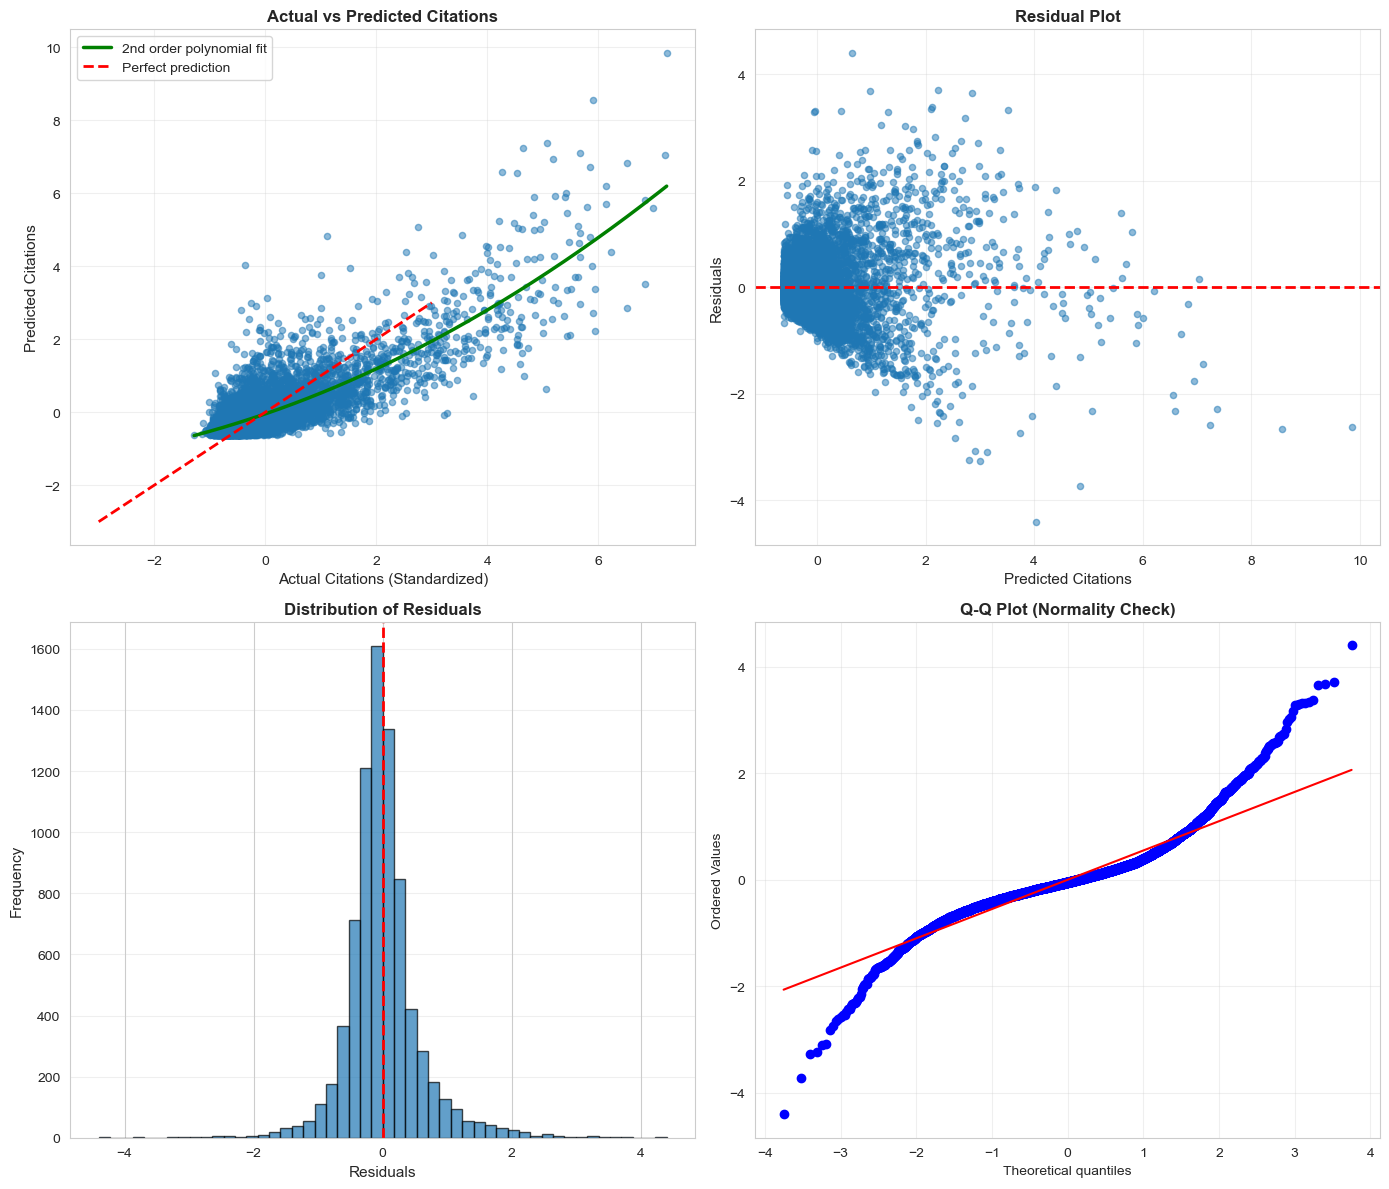

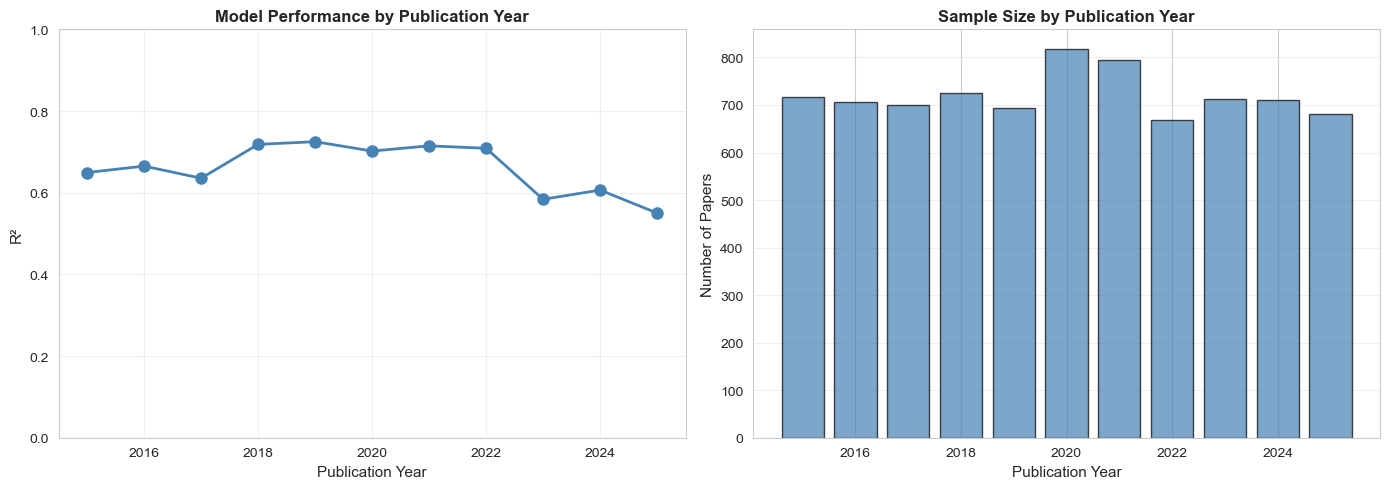

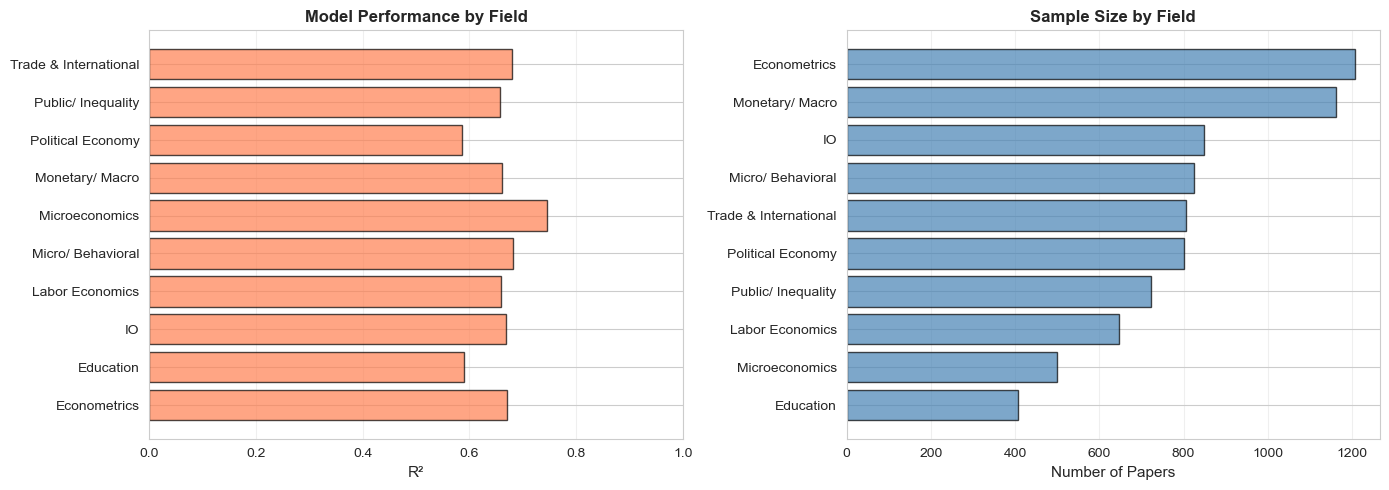

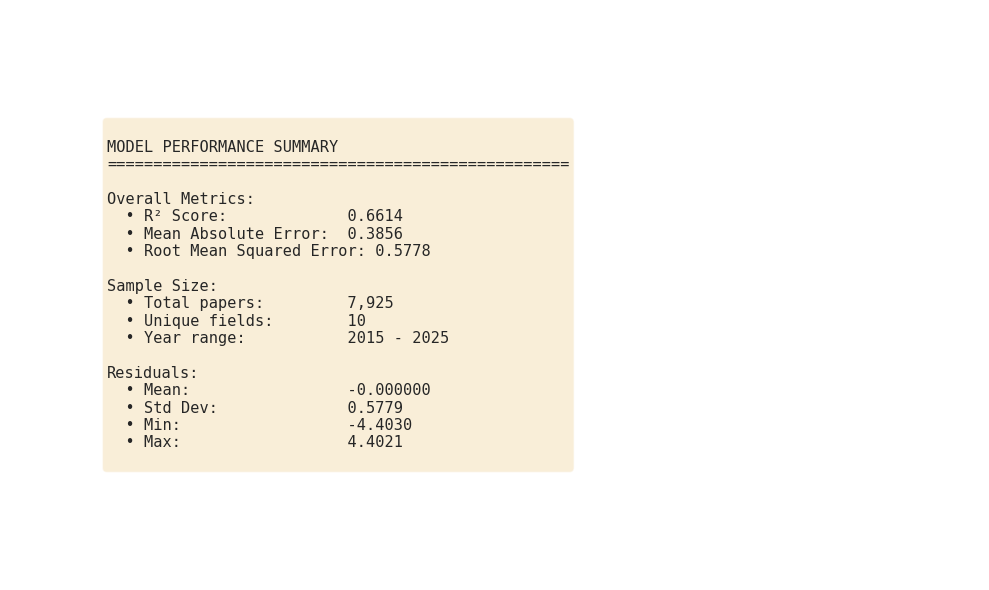

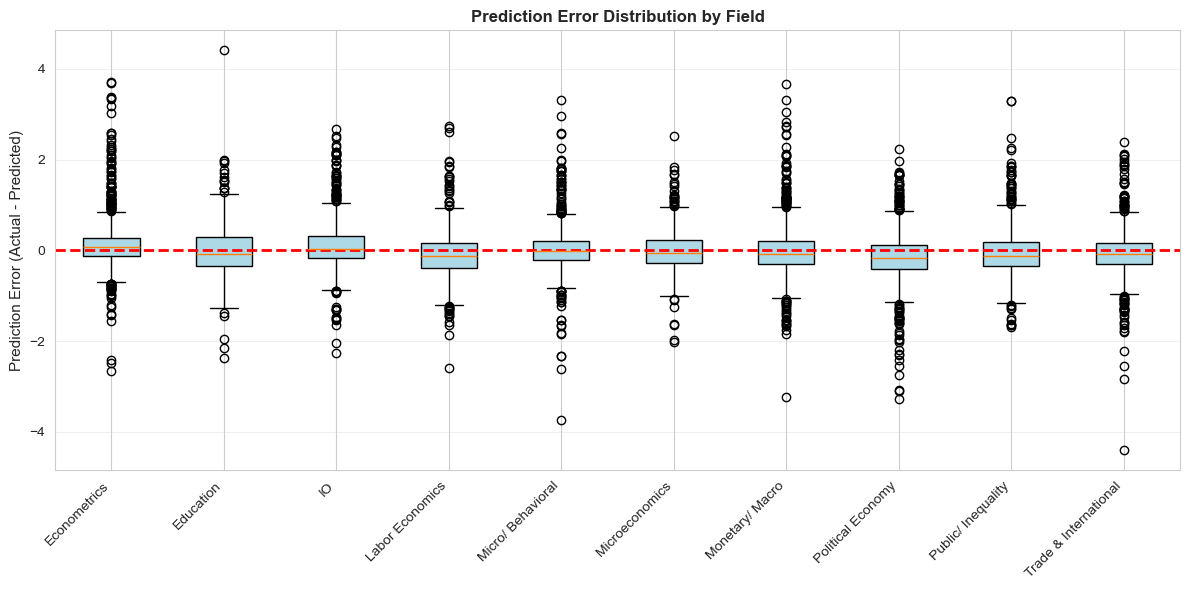


✓ All plots generated successfully!


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ── 1. Actual vs Predicted (Overall) ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scatter plot with 2nd order polynomial fit line
ax = axes[0, 0]
ax.scatter(df['citations_std'], df['citations_predicted'], alpha=0.5, s=20)

# Add 2nd order polynomial fit line
sort_idx = np.argsort(df['citations_std'].values)
x_sorted = df['citations_std'].values[sort_idx]
y_sorted = df['citations_predicted'].values[sort_idx]

# Fit polynomial to actual vs predicted
poly_fit = np.polyfit(x_sorted, y_sorted, 2)
poly_fn = np.poly1d(poly_fit)
x_smooth = np.linspace(x_sorted.min(), x_sorted.max(), 300)
y_smooth = poly_fn(x_smooth)

ax.plot(x_smooth, y_smooth, 'g-', lw=2.5, label='2nd order polynomial fit')
ax.plot([-3, 3], [-3, 3], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Citations (Standardized)', fontsize=11)
ax.set_ylabel('Predicted Citations', fontsize=11)
ax.set_title('Actual vs Predicted Citations', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals
ax = axes[0, 1]
residuals = df['citations_std'] - df['citations_predicted']
ax.scatter(df['citations_predicted'], residuals, alpha=0.5, s=20)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted Citations', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Residual distribution
ax = axes[1, 0]
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Residuals', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Q-Q plot (normality check)
from scipy import stats
ax = axes[1, 1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 2. R² by Publication Year ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² trend over years
ax = axes[0]
r2_by_year = []
years = []
for yr in sorted(df['publication_year'].unique()):
    grp = df[df['publication_year'] == yr]
    if len(grp) > 5:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        r2_by_year.append(r2)
        years.append(yr)

ax.plot(years, r2_by_year, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel('Publication Year', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Model Performance by Publication Year', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

# Sample size by year
ax = axes[1]
sample_counts = df.groupby('publication_year').size()
ax.bar(sample_counts.index, sample_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Publication Year', fontsize=11)
ax.set_ylabel('Number of Papers', fontsize=11)
ax.set_title('Sample Size by Publication Year', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ── 3. R² by Field ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² by field
ax = axes[0]
r2_by_field = []
fields = []
for field in sorted(df['field'].unique()):
    grp = df[df['field'] == field]
    if len(grp) > 5:
        r2 = r2_score(grp['citations_std'], grp['citations_predicted'])
        r2_by_field.append(r2)
        fields.append(field)

ax.barh(fields, r2_by_field, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('R²', fontsize=11)
ax.set_title('Model Performance by Field', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

# Sample size by field
ax = axes[1]
sample_counts = df.groupby('field').size().sort_values(ascending=True)
ax.barh(sample_counts.index, sample_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Number of Papers', fontsize=11)
ax.set_title('Sample Size by Field', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── 4. Error metrics ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

overall_r2 = r2_score(df['citations_std'], df['citations_predicted'])
overall_mae = mean_absolute_error(df['citations_std'], df['citations_predicted'])
overall_rmse = np.sqrt(mean_squared_error(df['citations_std'], df['citations_predicted']))

metrics_text = f"""
MODEL PERFORMANCE SUMMARY
{'='*50}

Overall Metrics:
  • R² Score:             {overall_r2:.4f}
  • Mean Absolute Error:  {overall_mae:.4f}
  • Root Mean Squared Error: {overall_rmse:.4f}

Sample Size:
  • Total papers:         {len(df):,}
  • Unique fields:        {df['field'].nunique()}
  • Year range:           {df['publication_year'].min():.0f} - {df['publication_year'].max():.0f}

Residuals:
  • Mean:                 {residuals.mean():.6f}
  • Std Dev:              {residuals.std():.4f}
  • Min:                  {residuals.min():.4f}
  • Max:                  {residuals.max():.4f}
"""

ax.text(0.1, 0.5, metrics_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='center', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.tight_layout()
plt.show()

# ── 5. Prediction Error Distribution by Field ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

error_data = []
field_labels = []
for field in sorted(df['field'].unique()):
    grp = df[df['field'] == field]
    errors = grp['citations_std'] - grp['citations_predicted']
    error_data.append(errors)
    field_labels.append(field)

bp = ax.boxplot(error_data, labels=field_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_ylabel('Prediction Error (Actual - Predicted)', fontsize=11)
ax.set_title('Prediction Error Distribution by Field', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n✓ All plots generated successfully!")

TOP 30 WORDS PREDICTING HIGH CITATIONS (Positive Coefficients)
        feature  coefficient
          china     1.175182
        bitcoin     0.962630
        generat     0.916209
 social respons     0.886082
           firm     0.885019
             ai     0.803644
           next     0.775148
         econom     0.773210
         corpor     0.771131
       platform     0.734338
           race     0.710955
        sustain     0.702403
            jel     0.700468
         pandem     0.700026
   social media     0.689579
         pollut     0.647712
            gap     0.646993
estim heterogen     0.644338
    environment     0.630342
         financ     0.624877
 social respons     0.623565
        percent     0.619702
       facebook     0.619113
       forecast     0.618494
          digit     0.617382
        bitcoin     0.597010
        privaci     0.594035
         consum     0.586650
          estim     0.586481
         climat     0.582861

TOP 30 WORDS PREDICTING LOW CITATIONS

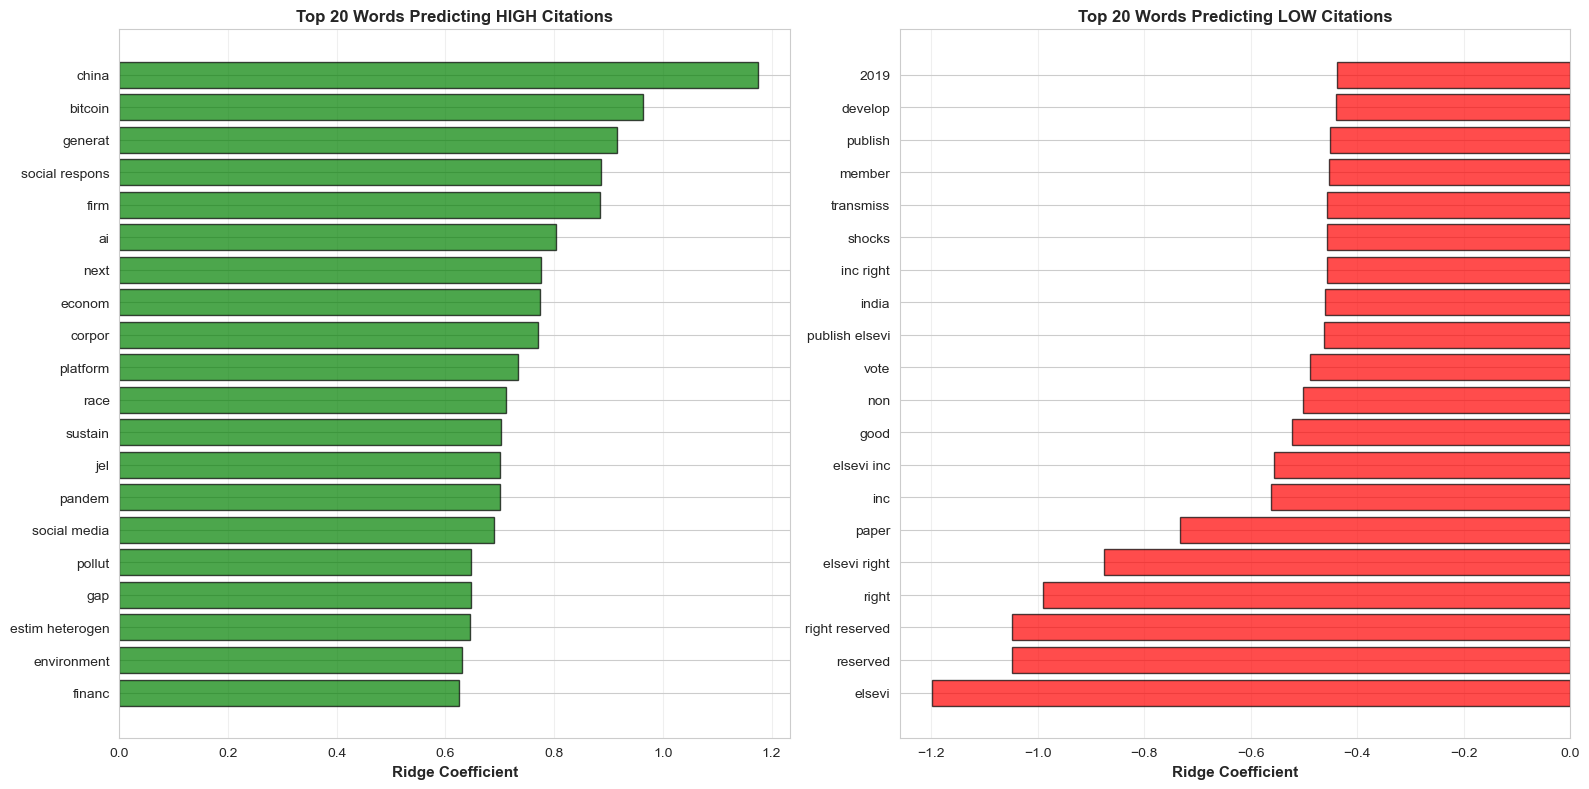


✓ Feature importance saved to feature_importance.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# ── 1. Get Ridge coefficients ────────────────────────────────────────────────
# Ridge coefficients for TF-IDF features
ridge_coef = ridge.coef_

# Get feature names
title_features = vec_titles.get_feature_names_out()
abstract_features = vec_abstracts.get_feature_names_out()

# Combine all feature names
all_features = np.concatenate([title_features, abstract_features])

# Create dataframe of features and coefficients
feature_importance = pd.DataFrame({
    'feature': all_features,
    'coefficient': ridge_coef
})

# Sort by absolute coefficient value (both positive and negative)
feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

# ── 2. Top words predicting HIGH citations (positive coefficients) ──────────
print("="*70)
print("TOP 30 WORDS PREDICTING HIGH CITATIONS (Positive Coefficients)")
print("="*70)

high_citation_words = feature_importance[feature_importance['coefficient'] > 0].head(30)
print(high_citation_words[['feature', 'coefficient']].to_string(index=False))

# ── 3. Top words predicting LOW citations (negative coefficients) ──────────
print("\n" + "="*70)
print("TOP 30 WORDS PREDICTING LOW CITATIONS (Negative Coefficients)")
print("="*70)

low_citation_words = feature_importance[feature_importance['coefficient'] < 0].head(30)
low_citation_words_sorted = low_citation_words.sort_values('coefficient')
print(low_citation_words_sorted[['feature', 'coefficient']].to_string(index=False))

# ── 4. Visualize top words ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# High citation words
ax = axes[0]
top_high = feature_importance[feature_importance['coefficient'] > 0].head(20)
top_high = top_high.sort_values('coefficient')
ax.barh(top_high['feature'], top_high['coefficient'], color='green', alpha=0.7, edgecolor='black')
ax.set_xlabel('Ridge Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Words Predicting HIGH Citations', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Low citation words
ax = axes[1]
top_low = feature_importance[feature_importance['coefficient'] < 0].head(20)
top_low = top_low.sort_values('coefficient')
ax.barh(top_low['feature'], top_low['coefficient'], color='red', alpha=0.7, edgecolor='black')
ax.set_xlabel('Ridge Coefficient', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Words Predicting LOW Citations', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('word_importance.png', dpi=300, bbox_inches='tight')
plt.show()



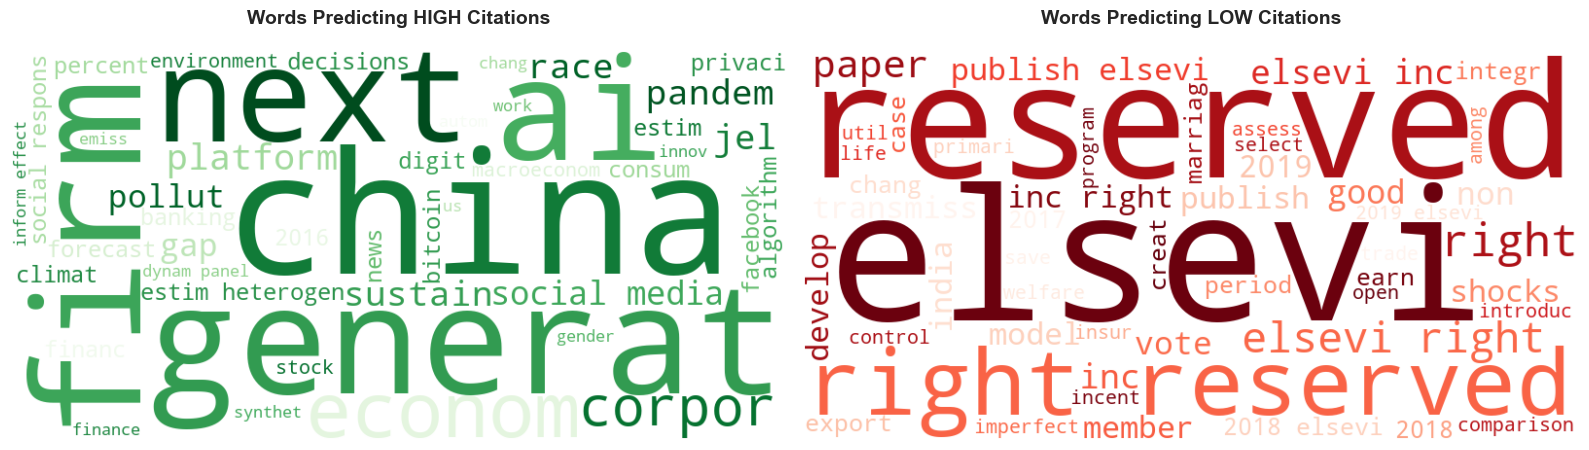

✓ Word clouds saved to data\predict_citations\wordcloud_citations.png
✓ Feature importance saved to data\predict_citations\feature_importance.csv
✓ Predictions saved to data\predict_citations\predicted_citations.csv


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import os

# ── 1. Prepare data for word clouds ──────────────────────────────────────────

# High citation words
high_citation_words = feature_importance[feature_importance['coefficient'] > 0].head(50)
high_word_dict = dict(zip(high_citation_words['feature'], high_citation_words['coefficient']))

# Low citation words
low_citation_words = feature_importance[feature_importance['coefficient'] < 0].head(50)
low_word_dict = dict(zip(low_citation_words['feature'], np.abs(low_citation_words['coefficient'])))

# ── 3. Create word clouds ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# High citations word cloud
ax = axes[0]
wc_high = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='Greens',
    relative_scaling=0.5,
    min_font_size=10
).generate_from_frequencies(high_word_dict)

ax.imshow(wc_high, interpolation='bilinear')
ax.set_title('Words Predicting HIGH Citations', fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

# Low citations word cloud
ax = axes[1]
wc_low = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='Reds',
    relative_scaling=0.5,
    min_font_size=10
).generate_from_frequencies(low_word_dict)

ax.imshow(wc_low, interpolation='bilinear')
ax.set_title('Words Predicting LOW Citations', fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

plt.tight_layout()
wordcloud_path = os.path.join(output_dir, 'wordcloud_citations.png')
plt.savefig(wordcloud_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Word clouds saved to {wordcloud_path}")

# ── 4. Save feature importance to CSV ────────────────────────────────────────
csv_path = os.path.join(output_dir, 'feature_importance.csv')
feature_importance.to_csv(csv_path, index=False)
print(f"✓ Feature importance saved to {csv_path}")

# ── 5. Save predictions to CSV ───────────────────────────────────────────────
out = df[['paper_id', 'publication_year', 'citations',
          'citations_wins', 'citations_std', 'citations_predicted']]
out.to_csv(os.path.join(output_dir, 'predicted_citations.csv'), index=False)
print(f"Saved to {predictions_path}")